In [89]:
import uproot,json,os
import ROOT
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
from scipy import stats
import itertools

In [90]:
def getXProjections(x_arr,y_arr,nMinProj=-1):
    xU = np.unique(x_arr)
    xVal     =[]     
    xProj    =[]
    xProj_err=[]
    for x in xU:
        mask= x_arr==x
        if np.sum(mask) < nMinProj:
            continue
        avg = np.average( y_arr[mask] )
        std = np.std( y_arr[mask] )
        xProj.append(avg)
        xProj_err.append(std)
        xVal.append(x)
    return {'x':np.array(xVal) , 'projection' : np.array(xProj) , 'stdev' : np.array(xProj_err) }

In [91]:
compressionNTTMap=np.array([0,0,0,0,0,0,1,1,1,1,1,2,2,2,2,2,3,3,3,3,3,
                         4,4,4,4,4,5,5,5,5,5,6,6,6,6,6,7,7,7,7,7,8
                         ,8,8,8,8,9,9,9,9,9,10,10,10,10,10,
                         11,11,11,11,11,12,12,12,12,12,13,13,13,13,13,
                         14,14,14,14,14,15,15,15,15,15,16,16,16,16,16,
                         17,17,17,17,17,18,18,18,18,18,19,19,19,19,19,
                         20,20,20,20,20,21,21,21,21,21,22,22,22,22,22,
                         23,23,23,23,23,24,24,24,24,24,25,25,25,25,25,
                         26,26,26,26,26,27,27,27,27,27,28,28,28,28,28,
                         29,29,29,29,29,30,30,30,30,30,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,])

compressionRawEtMap=np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 
                              7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 17, 
                              17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 21,21, 21, 22, 22, 22, 22, 23, 23, 23, 23, 24, 
                              24, 24, 24, 25, 25, 25, 25, 25, 26, 26, 26,26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 28, 
                              28, 28, 28, 28, 28, 28, 28, 28, 28, 29, 29,29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 
                              29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 
                              30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31]
                            )

compressionEtaMap=np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 
                            2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 
                            3, 3, 3, 3, 3, 3, 3, 3]
)

In [92]:
hep.style.use("CMS")

matplotlib.rcParams['figure.figsize'] = (6, 5.5)
matplotlib.rcParams['figure.dpi'] = 100

In [93]:
prefix='/data_CMS/cms/amella/Run3_2025/'
# fname='HCALcFeb-caloParams_2025_conservative-ZS-MC25W_CALIBRATED_corrected.root'
fname=prefix+'MC2025_caloparams-2025/MC2025-caloparams-2025.root'

In [94]:
file= uproot.open(fname)

In [95]:
file.keys()

['Ntuplizer_noTagAndProbe;1',
 'Ntuplizer_noTagAndProbe/triggerNames;1',
 'Ntuplizer_noTagAndProbe/TagAndProbe;1']

In [96]:
data=file['Ntuplizer_noTagAndProbe/TagAndProbe']

In [97]:
varsToGet=['tauPt','tauEta','tauPhi','tauCharge',
'l1tPt','l1tEta','l1tE','l1tPhi','l1tQual','l1tIso',
'l1tEmuPt','l1tEmuEta','l1tEmuPhi','l1tEmuQual','l1tEmuIso',
'l1tEmuNTT','l1tEmuHasEM','l1tEmuIsMerged','l1tEmuTowerIEta','Nvtx',
'l1tEmuTowerIPhi','l1tEmuRawEt','l1tEmuIsoEt']


dataStore=data.arrays(varsToGet)
# dataStore=data.arrays(['l1tEmuPt','l1tEmuNTT','l1tEmuRawEt','RunNumber','l1tEmuTowerIEta','l1tEmuEta'])

puMask=dataStore['Nvtx'] > 0
# print(sum(puMask))

print(prefix)

os.system(f'mkdir -p {prefix}')

/data_CMS/cms/amella/Run3_2025/


0

In [98]:
# ['l1tEmuPt','l1tEmuNTT','l1tEmuRawEt','RunNumber','l1tEmuTowerIEta','l1tEmuEta']

In [99]:
# dataStore['l1tEmuIsoEt']=dataStore.L1Tau_Iso

# dataStore['l1tEmuPt']=dataStore.L1Tau_pt

# dataStore['l1tEmuTowerIEta']=dataStore.L1Tau_IEta

# dataStore['l1tEmuNTT']=dataStore.L1Tau_nTT

# dataStore['l1tEmuRawEt']=dataStore.L1Tau_IEt

In [100]:
# dataMask=np.logical_and(dataStore['Nvtx'] > 20,dataStore['l1tEmuRawEt'] > 0)
# dataStore=dataStore[dataMask]

In [101]:
intNTT=np.array(dataStore['l1tEmuNTT'],dtype=int)
print(len(intNTT))
dataStore['compressedNTT']=compressionNTTMap[intNTT]
print(len(compressionNTTMap))

570402
1024


/tmp/ipykernel_963874/2863546087.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intNTT=np.array(dataStore['l1tEmuNTT'],dtype=int)


In [102]:
intRawEt=np.array(dataStore['l1tEmuRawEt'],dtype=int)
intRawEt[intRawEt>255]=255
dataStore['compressedRawEt']=compressionRawEtMap[intRawEt]

/tmp/ipykernel_963874/179787973.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intRawEt=np.array(dataStore['l1tEmuRawEt'],dtype=int)


In [103]:
intIEta=np.abs(np.array(dataStore['l1tEmuTowerIEta'],dtype=int))
dataStore['compressedIEta']=compressionEtaMap[intIEta]

/tmp/ipykernel_963874/3372110035.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intIEta=np.abs(np.array(dataStore['l1tEmuTowerIEta'],dtype=int))


In [104]:
saveFig=True

## Plotting distributions from data

Plotting Nvtx

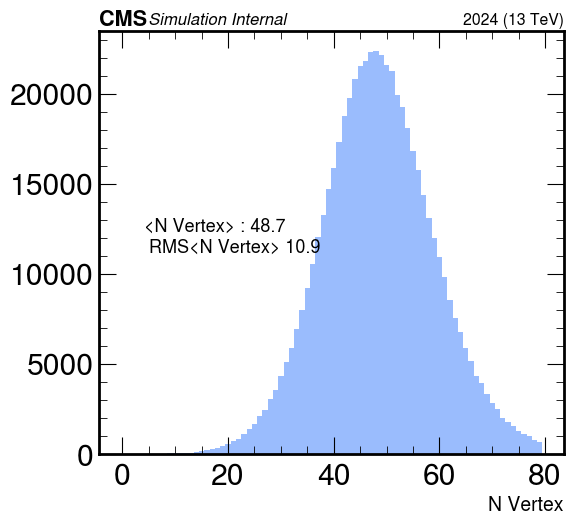

In [105]:
_=plt.hist(dataStore['Nvtx'],np.arange(-0.5,80.0,1),alpha=0.6)
mu=np.average(dataStore['Nvtx'])
stdev=np.std(dataStore['Nvtx'])
plt.text(4,max(_[0])*0.5,f"<N Vertex> : {mu:.1f}\n RMS<N Vertex> {stdev:.1f}",fontsize=13)
plt.xlabel('N Vertex',fontsize=14)
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
hep.cms.label('Internal',fontsize=12,data=False,year='2024')
if saveFig:
    plt.savefig(f'{prefix}/pu.png',bbox_inches='tight')

Plotting NTT

/tmp/ipykernel_963874/292856813.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intNTT=np.array(dataStore['l1tEmuNTT'][gMask],dtype=int)


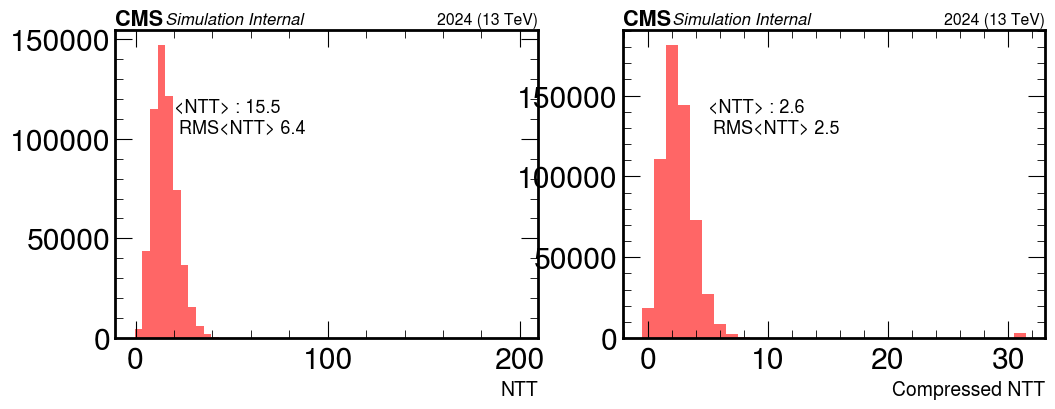

In [106]:
gMask=dataStore['l1tEmuNTT']>0
intNTT=np.array(dataStore['l1tEmuNTT'][gMask],dtype=int)
compressedNTT=dataStore['compressedNTT']
f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuNTT'][gMask],np.arange(-0.5,200.0,4),alpha=0.6,color='r')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
mu=np.average(dataStore['l1tEmuNTT'][gMask])
stdev=np.std(dataStore['l1tEmuNTT'][gMask])
ax[0].text(20,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('NTT',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(compressedNTT,np.arange(-0.5,32.0,1),alpha=0.6,color='r')
mu=np.average(compressedNTT)
stdev=np.std(compressedNTT)
ax[1].text(5,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('Compressed NTT',fontsize=14)
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
if saveFig:
    plt.savefig(f'{prefix}/compressedNTT.png',bbox_inches='tight')
# plt.semilogy()

Plotting Iso Et

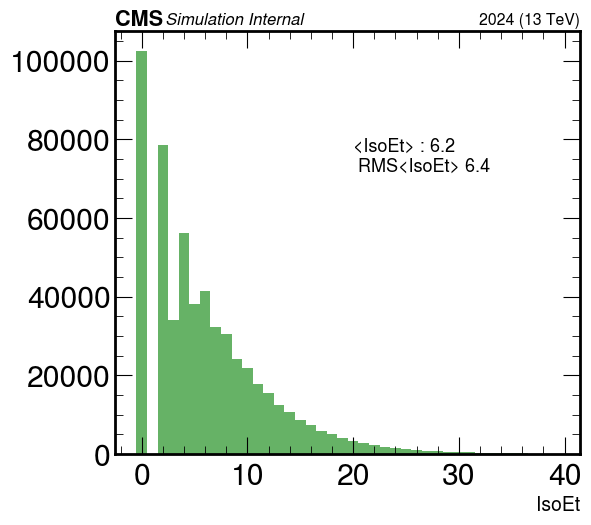

In [107]:
_=plt.hist(dataStore['l1tEmuIsoEt'],np.arange(-0.5,40.0,1),alpha=0.6,color='g')
mu=np.average(dataStore['l1tEmuIsoEt'])
stdev=np.std(dataStore['l1tEmuIsoEt'])
plt.text(20,max(_[0])*0.7,f"<IsoEt> : {mu:.1f}\n RMS<IsoEt> {stdev:.1f}",fontsize=13)
plt.xlabel('IsoEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/IsoEt.png',bbox_inches='tight')

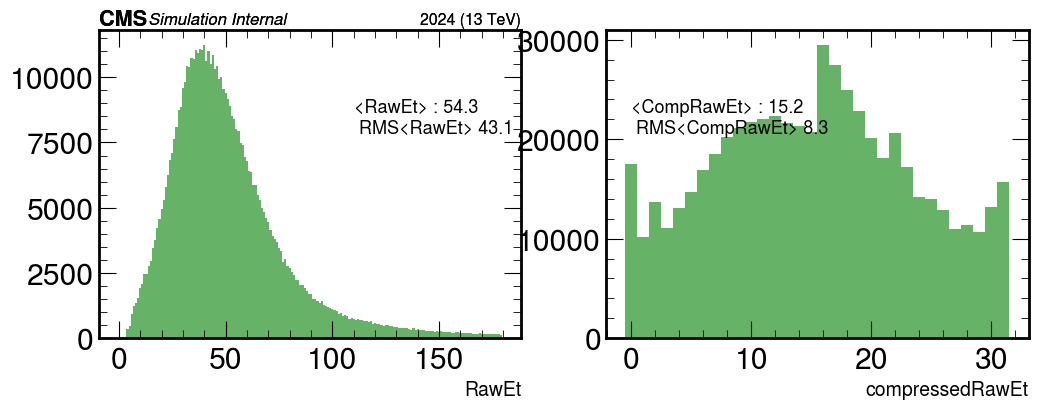

In [108]:

f,ax=plt.subplots(1,2,figsize=(12,4))
_=ax[0].hist(dataStore['l1tEmuRawEt'],np.arange(-0.5,180.0,1),alpha=0.6,color='g')
mu=np.average(dataStore['l1tEmuRawEt'])
stdev=np.std(dataStore['l1tEmuRawEt'])
ax[0].text(110,max(_[0])*0.7,f"<RawEt> : {mu:.1f}\n RMS<RawEt> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('RawEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])


_=ax[1].hist(dataStore['compressedRawEt'],np.arange(-0.5,32.0,1),alpha=0.6,color='g')
mu=np.average(dataStore['compressedRawEt'])
stdev=np.std(dataStore['compressedRawEt'])
ax[1].text(0,max(_[0])*0.7,f"<CompRawEt> : {mu:.1f}\n RMS<CompRawEt> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedRawEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedRawEt.png',bbox_inches='tight')

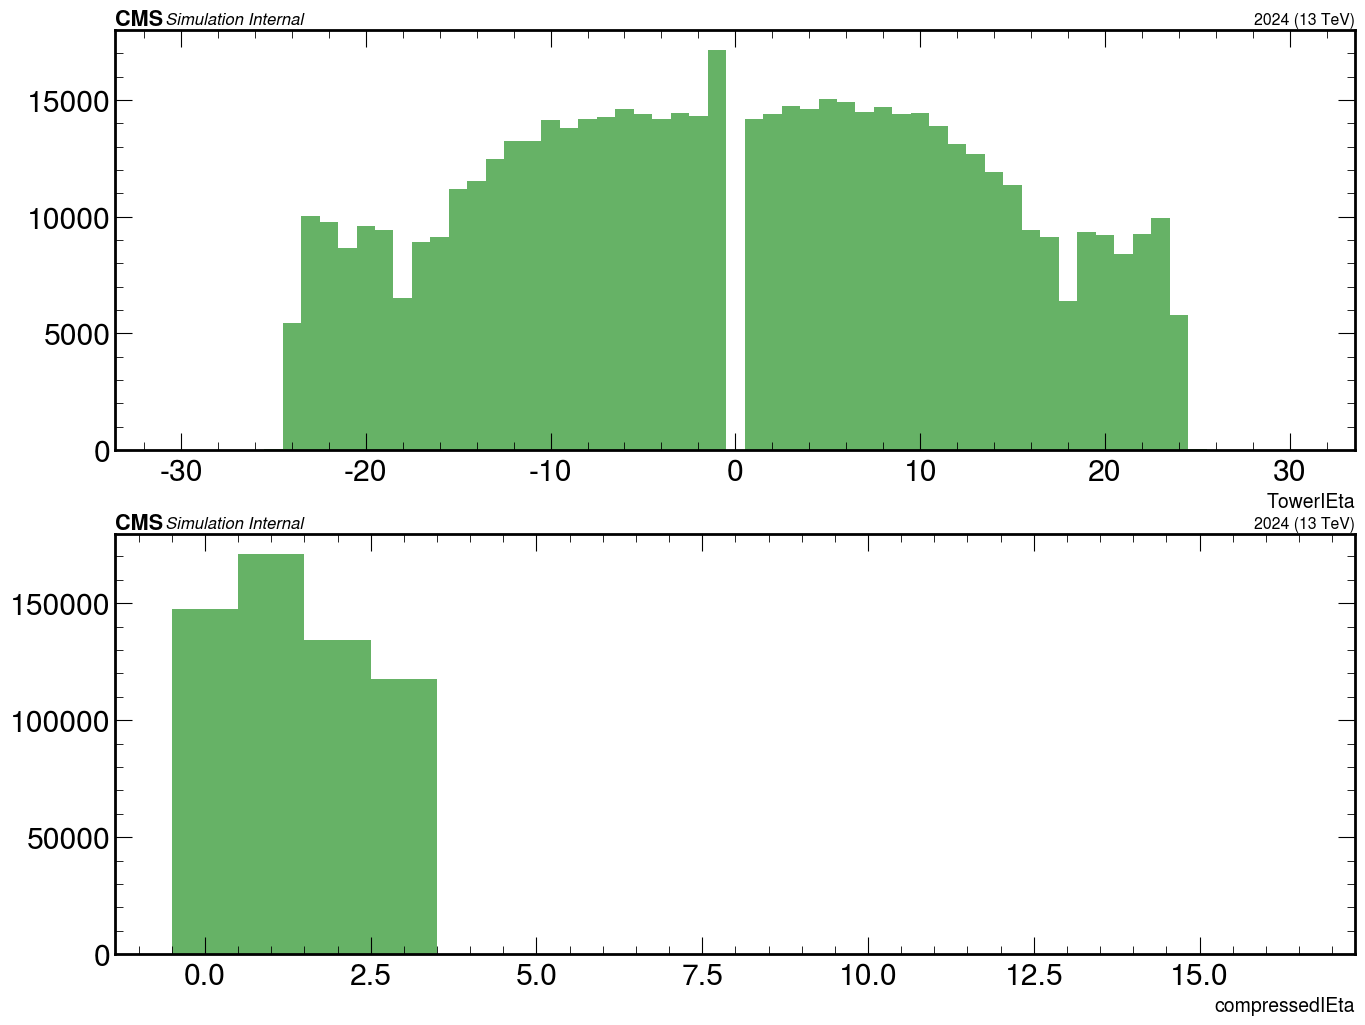

In [109]:
f,ax=plt.subplots(2,1,figsize=(16,12))
_=ax[0].hist(dataStore['l1tEmuTowerIEta'],np.arange(-30.5,31.0,1),alpha=0.6,color='g')
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('TowerIEta',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(dataStore['compressedIEta'],np.arange(-0.5,17.0,1),alpha=0.6,color='g')
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedIEta',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedIEta.png',bbox_inches='tight')

In [110]:
bin_splits={
#     'compressedIEta' : [[0,0],[1,1],[2,2],[3,3]],
    'compressedIEta' : [[0,1],[2,3]],
    'compressedRawEt' : [[2*i,2*i+1] for i in range(16)],
}

In [111]:
binned_data={}

In [112]:
bin_dim_names=list(bin_splits.keys())
print(bin_dim_names)

['compressedIEta', 'compressedRawEt']


In [113]:
bins_bounds_=list(itertools.product(*[bin_splits[ky] for ky in bin_dim_names]))
print(bins_bounds_)

[([0, 1], [0, 1]), ([0, 1], [2, 3]), ([0, 1], [4, 5]), ([0, 1], [6, 7]), ([0, 1], [8, 9]), ([0, 1], [10, 11]), ([0, 1], [12, 13]), ([0, 1], [14, 15]), ([0, 1], [16, 17]), ([0, 1], [18, 19]), ([0, 1], [20, 21]), ([0, 1], [22, 23]), ([0, 1], [24, 25]), ([0, 1], [26, 27]), ([0, 1], [28, 29]), ([0, 1], [30, 31]), ([2, 3], [0, 1]), ([2, 3], [2, 3]), ([2, 3], [4, 5]), ([2, 3], [6, 7]), ([2, 3], [8, 9]), ([2, 3], [10, 11]), ([2, 3], [12, 13]), ([2, 3], [14, 15]), ([2, 3], [16, 17]), ([2, 3], [18, 19]), ([2, 3], [20, 21]), ([2, 3], [22, 23]), ([2, 3], [24, 25]), ([2, 3], [26, 27]), ([2, 3], [28, 29]), ([2, 3], [30, 31])]


In [114]:
def getBinName(bin_dim_names,bin_bounds):
    name="_"
    for bn,bb in zip(bin_dim_names,bin_bounds):
        name+=f"{bn}IN{bb}_"
    return name.replace(" ","")


In [115]:
bins_bounds={getBinName(bin_dim_names,bb) : bb for bb in bins_bounds_}
# for i in bins_bounds:
#     print(i,bins_bounds[i])    
print(bins_bounds)

{'_compressedIEtaIN[0,1]_compressedRawEtIN[0,1]_': ([0, 1], [0, 1]), '_compressedIEtaIN[0,1]_compressedRawEtIN[2,3]_': ([0, 1], [2, 3]), '_compressedIEtaIN[0,1]_compressedRawEtIN[4,5]_': ([0, 1], [4, 5]), '_compressedIEtaIN[0,1]_compressedRawEtIN[6,7]_': ([0, 1], [6, 7]), '_compressedIEtaIN[0,1]_compressedRawEtIN[8,9]_': ([0, 1], [8, 9]), '_compressedIEtaIN[0,1]_compressedRawEtIN[10,11]_': ([0, 1], [10, 11]), '_compressedIEtaIN[0,1]_compressedRawEtIN[12,13]_': ([0, 1], [12, 13]), '_compressedIEtaIN[0,1]_compressedRawEtIN[14,15]_': ([0, 1], [14, 15]), '_compressedIEtaIN[0,1]_compressedRawEtIN[16,17]_': ([0, 1], [16, 17]), '_compressedIEtaIN[0,1]_compressedRawEtIN[18,19]_': ([0, 1], [18, 19]), '_compressedIEtaIN[0,1]_compressedRawEtIN[20,21]_': ([0, 1], [20, 21]), '_compressedIEtaIN[0,1]_compressedRawEtIN[22,23]_': ([0, 1], [22, 23]), '_compressedIEtaIN[0,1]_compressedRawEtIN[24,25]_': ([0, 1], [24, 25]), '_compressedIEtaIN[0,1]_compressedRawEtIN[26,27]_': ([0, 1], [26, 27]), '_compresse

In [116]:
data_split_inBins={}

In [117]:
nbins=len(bins_bounds)
print(nbins)
print(len(dataStore['compressedRawEt']))

32
570402


In [118]:
bin_mask=np.ones(len(dataStore['Nvtx']),dtype=bool)
print(bin_mask)

[ True  True  True ...  True  True  True]


In [119]:
for i,bn_name in enumerate(bins_bounds):
    print(f"\rProcessing bin {i+1}/{nbins}\n",end="")
    bin_mask=dataStore['compressedIEta'] > -1
    for bn,bb in zip(bin_dim_names,bins_bounds[bn_name]):
        # print(f"   > {bn} : {bb[0]}")
        # print(f"   > {bn} : {bb[1]}")
        # For example for the first bin_dim_names 'compressedIEta' and bounds [0,1]
        # we will have bin_mask=np.logical_and(bin_mask,dataStore['compressedIEta']>0)
        # and bin_mask=np.logical_and(bin_mask,dataStore['compressedIEta']<1)
        # which will filter the dataStore to only include events where 'compressedIEta' is between 0 and 1
        bin_mask=np.logical_and(bin_mask,dataStore[bn]>=bb[0])
        bin_mask=np.logical_and(bin_mask,dataStore[bn]<=bb[1])
    n=np.sum(bin_mask)
    print(n)
    if n < 2000:
        print("   > NEvents : ",n)
        print()
    data_split_inBins[bn_name]=dataStore[bin_mask]

print(len(data_split_inBins))
    

Processing bin 1/32
14611
Processing bin 2/32
13062
Processing bin 3/32
14716
Processing bin 4/32
18896
Processing bin 5/32
22278
Processing bin 6/32
23731
Processing bin 7/32
23955
Processing bin 8/32
23272
Processing bin 9/32
31588
Processing bin 10/32
26598
Processing bin 11/32
21726
Processing bin 12/32
21790
Processing bin 13/32
16398
Processing bin 14/32
14152
Processing bin 15/32
13046
Processing bin 16/32
18707
Processing bin 17/32
13025
Processing bin 18/32
11724
Processing bin 19/32
13074
Processing bin 20/32
16435
Processing bin 21/32
19118
Processing bin 22/32
19989
Processing bin 23/32
19984
Processing bin 24/32
18824
Processing bin 25/32
25390
Processing bin 26/32
21141
Processing bin 27/32
16516
Processing bin 28/32
15979
Processing bin 29/32
11794
Processing bin 30/32
9718
Processing bin 31/32
9022
Processing bin 32/32
10143
32


Plotting IsoEt vs NTT

/tmp/ipykernel_963874/2283277554.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax[ifig].hist2d(np.array(ldta['compressedNTT']),
/tmp/ipykernel_963874/2283277554.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(ldta['l1tEmuIsoEt']),


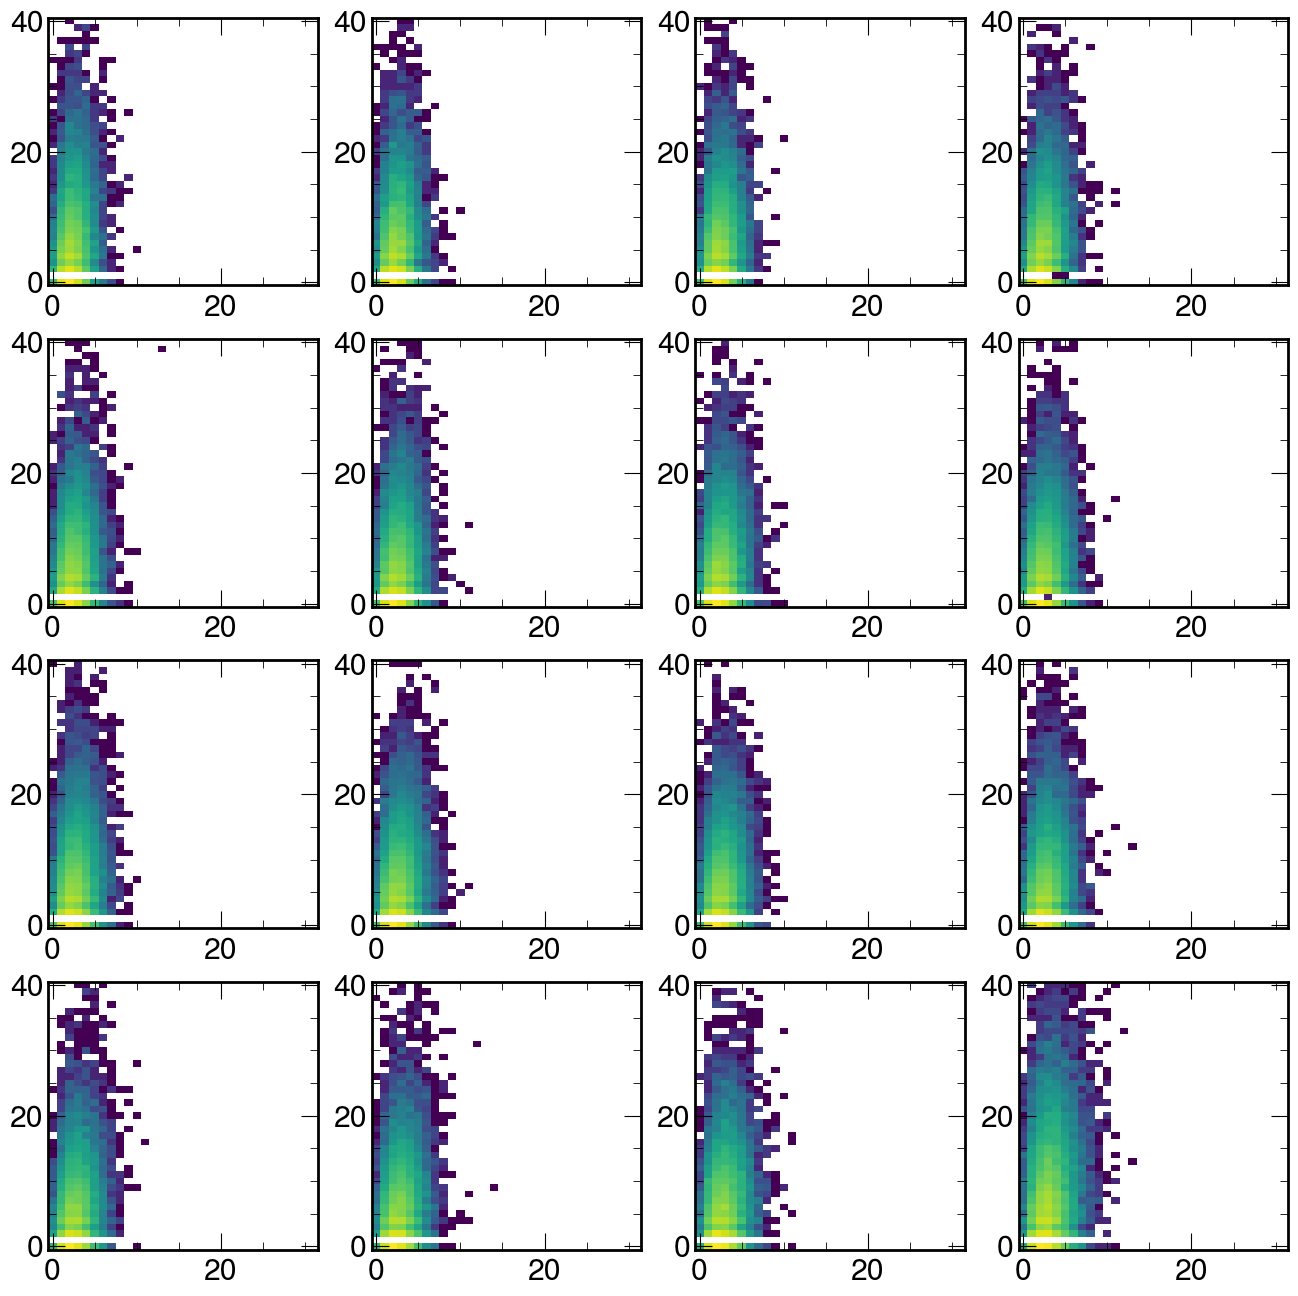

In [120]:
f,ax=None,None
ifig=-1
BINS=[np.arange(-0.5,32,1),np.arange(-0.5,41,1)]
nfig=0
for i,bn_name in enumerate(data_split_inBins):
    ifig+=1
    if ifig==16 or (f is None):
        nfig+=1
        if nfig>1:
            break
        f,ax=plt.subplots(4,4,figsize=(16,16))
        ax=np.ndarray.flatten(ax)
        ifig=0
    ldta=data_split_inBins[bn_name]
    ax[ifig].hist2d(np.array(ldta['compressedNTT']),
                    np.array(ldta['l1tEmuIsoEt']),
                    norm='log',
                    bins=BINS)

In [121]:
extracted_data={}

for i,bin_name in enumerate(data_split_inBins):
    print(f"\rProcessing bin {i+1}/{nbins}",end="")
    print(f"{bin_name}")
    ldta=data_split_inBins[bin_name]
    # print(ldta)
    x,y=np.array(ldta['compressedNTT']),np.array(ldta['l1tEmuIsoEt'])
    projection_default=getXProjections(x,y)
    extracted_data[bin_name]={}
    extracted_data[bin_name]['c_ntt']  =projection_default['x']
    extracted_data[bin_name]['c_isoet']=projection_default['projection']
    extracted_data[bin_name]['c_isoet_std']=projection_default['stdev']
    fit_range_mask = x  > -100 # TRIVIAL MASK
    res = stats.linregress(x[fit_range_mask],y[fit_range_mask])
    extracted_data[bin_name]['linear_fit']={}
    extracted_data[bin_name]['linear_fit']["Remarks"] = "m*x+c"
    extracted_data[bin_name]['linear_fit']["c"] = res.intercept
    extracted_data[bin_name]['linear_fit']["m"] = res.slope
    print(extracted_data[bin_name]['linear_fit'])
    

Processing bin 1/32_compressedIEtaIN[0,1]_compressedRawEtIN[0,1]_
{'Remarks': 'm*x+c', 'c': np.float64(4.556768616284902), 'm': np.float64(0.942565832362197)}
Processing bin 2/32_compressedIEtaIN[0,1]_compressedRawEtIN[2,3]_
{'Remarks': 'm*x+c', 'c': np.float64(4.575727557843274), 'm': np.float64(0.784092824878286)}
Processing bin 3/32_compressedIEtaIN[0,1]_compressedRawEtIN[4,5]_
{'Remarks': 'm*x+c', 'c': np.float64(4.218867416252782), 'm': np.float64(0.7959695267494238)}
Processing bin 4/32_compressedIEtaIN[0,1]_compressedRawEtIN[6,7]_
{'Remarks': 'm*x+c', 'c': np.float64(3.8171623915244526), 'm': np.float64(0.8379806674683155)}
Processing bin 5/32_compressedIEtaIN[0,1]_compressedRawEtIN[8,9]_
{'Remarks': 'm*x+c', 'c': np.float64(3.736946111903651), 'm': np.float64(0.7874450234957759)}
Processing bin 6/32_compressedIEtaIN[0,1]_compressedRawEtIN[10,11]_
{'Remarks': 'm*x+c', 'c': np.float64(3.5775244880736357), 'm': np.float64(0.805016277865281)}
Processing bin 7/32_compressedIEtaIN[0,

/tmp/ipykernel_963874/2275658522.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x,y=np.array(ldta['compressedNTT']),np.array(ldta['l1tEmuIsoEt'])


Processing bin 15/32

Processing bin 32/32

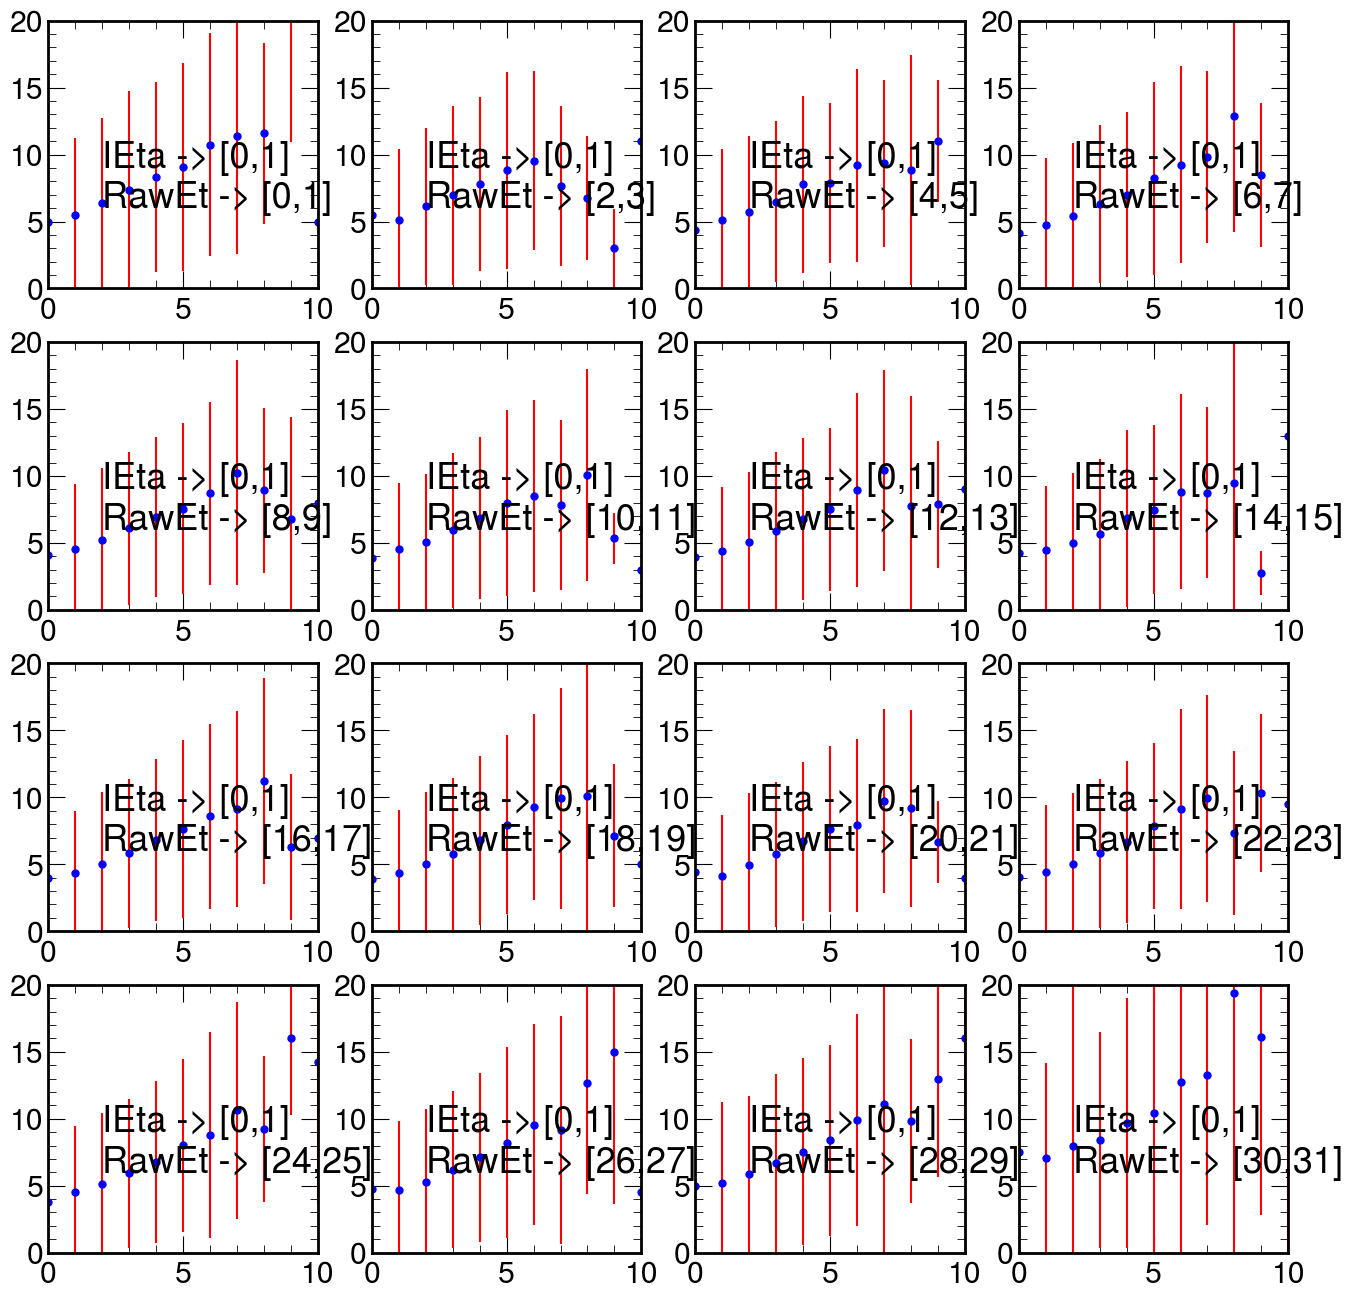

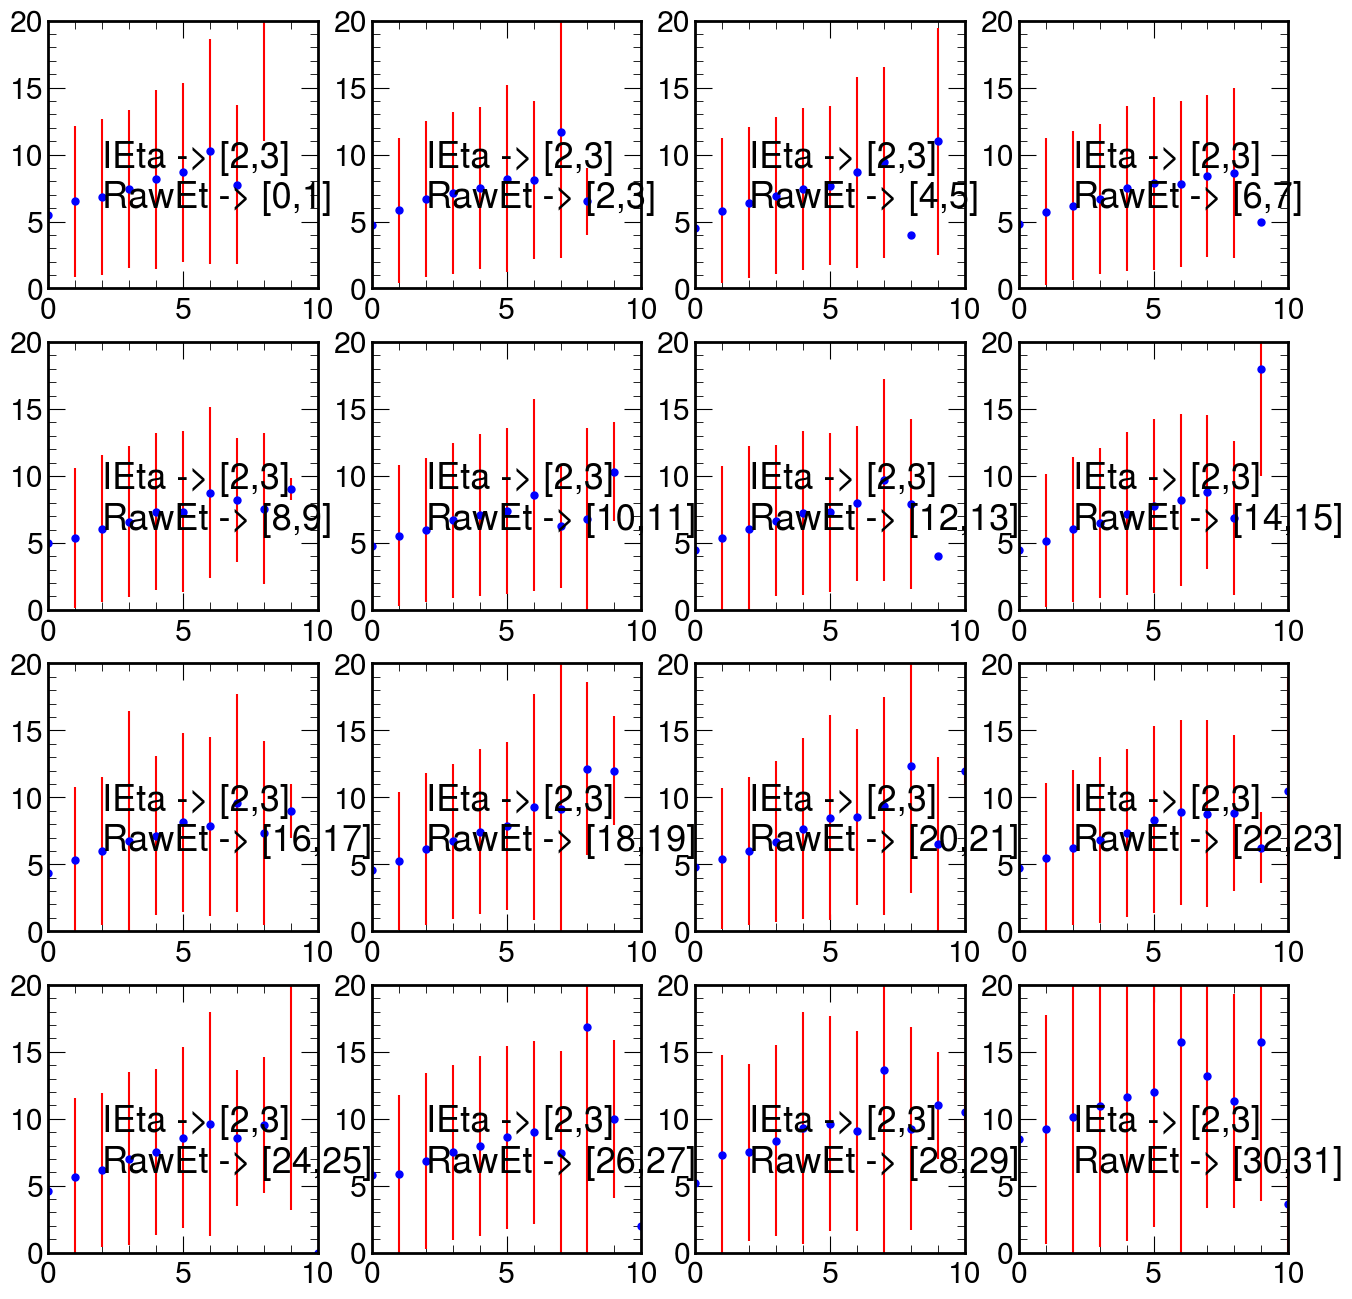

In [122]:
f,ax=None,None
ifig=-1
BINS=[np.arange(-0.5,32,1),np.arange(-0.5,41,1)]
nfig=0
for i,bin_name in enumerate(extracted_data):
    print(f"\rProcessing bin {i+1}/{nbins}",end="")
    ifig+=1
    if ifig==16 or (f is None):
        nfig+=1
        if nfig>10:
            break
        f,ax=plt.subplots(4,4,figsize=(16,16))
        ax=np.ndarray.flatten(ax)
        ifig=0
#     ldta=data_split_inBins[bn_name]
#     ax[ifig].hist2d(np.array(ldta['compressedNTT']),
#                     np.array(ldta['l1tEmuIsoEt']),bins=BINS)
    lbl="\n".join(bin_name[1:-1].replace("compressed","").replace("IN"," -> ").split("_"))
    ax[ifig].text(2.0,6.0,lbl)
    ax[ifig].errorbar(extracted_data[bin_name]['c_ntt'],
             extracted_data[bin_name]['c_isoet'],
             yerr= extracted_data[bin_name]['c_isoet_std'],
             fmt='o',markersize=5,color='b',ecolor='r')

    ax[ifig].set_xlim([0,10])
    ax[ifig].set_ylim([0,20])

In [123]:
bin_name='_compressedIEtaIN[0,1]_compressedRawEtIN[0,1]_'

In [124]:
ldta=data_split_inBins[bin_name]

In [125]:
x,y=np.array(ldta['compressedNTT']),np.array(ldta['l1tEmuIsoEt'])
projection_default=getXProjections( x,y)

/tmp/ipykernel_963874/2555723910.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x,y=np.array(ldta['compressedNTT']),np.array(ldta['l1tEmuIsoEt'])


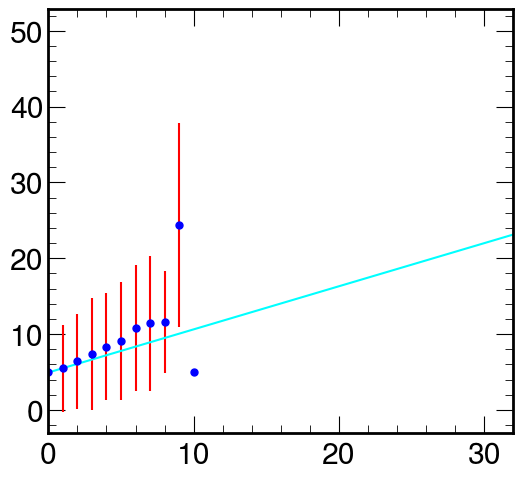

In [126]:
plt.errorbar(projection_default['x'],
             projection_default['projection'],
             yerr= projection_default['stdev'],
             fmt='o',markersize=5,color='b',ecolor='r')

plt.xlim([0,32])

x=projection_default['x']
y=projection_default['projection']
mask= np.logical_and(x>=0,x<2)
res = stats.linregress(x[mask],y[mask])

x= np.arange(0.0,80,0.2)
y=x*res.slope + res.intercept
plt.plot(x,y,color='cyan')

In [127]:
compressedEta_nbits=2
compressedEt_nbits=5
compressednTT_nbits=5

In [128]:
nEtaBins=1<<compressedEta_nbits
nNTTBins=1<<compressednTT_nbits
nEtBins =1<<compressedEt_nbits

In [129]:
def getBinForValues(bin_values,bin_splits,bin_dim_names):
    bins=[]
    for i in bin_dim_names:
        if i not in bin_splits:
            print(f"Bin splits does not have {i}")
            raise KeyError
        if i not in bin_values:
            print(f"Bin values does not have {i}")
            raise KeyError
        v=bin_values[i]
        gotBin=False
        for bn in bin_splits[i]:
            if (v<=bn[1]) and (v>=bn[0]):
                bins.append(bn)
                gotBin=True
        if not gotBin:
            print(f"For dim {i}, value {v} did not find a bin match !")
            raise KeyError
    return bins
            
        

In [130]:
def getXProjectionsAtPercentiles(x_arr,y_arr,quantile=50,nMinProj=20):
    xU = np.unique(x_arr)
    xVal     =[]     
    xProj    =[]
    xProj_err_up=[]
    xProj_err_dn=[]
    for x in xU:
        mask= x_arr==x
        if np.sum(mask) < nMinProj:
            continue
        val=np.percentile(y_arr[mask],quantile)
        n=np.sum(mask)
        var=y_arr[mask]-val
        varU=var[var>=0]
        varD=var[var<0]
        std_u=np.sqrt(np.sum(varU*varU)/n)
        std_d=np.sqrt(np.sum(varD*varD)/n)
        xProj_err_up.append(std_u)
        xProj_err_dn.append(std_d)
        
        xProj.append(val)
        xVal.append(x)
        
    return {'x':np.array(xVal) , 'projection' : np.array(xProj) ,
            'stdev_u' : np.array(xProj_err_up) ,'stdev_d' : np.array(xProj_err_dn) }

NameError: name 'proj' is not defined

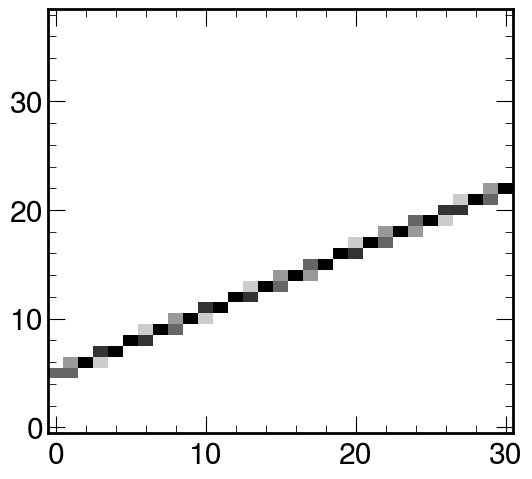

In [131]:
_=plt.hist2d(x,y,bins=[np.arange(32)-0.5,np.arange(40)-0.5],cmap='binary',)
plt.errorbar(proj['x'],proj['projection'],yerr=[proj['stdev_d'],proj['stdev_u']],fmt='o',)

In [ ]:
compressionRawEtMap[80]

np.int64(25)

In [ ]:

def getEfficiency(ieta,iet):
    if iet <12.0: # 20 GeV ( iet = 40) , compressed et =12  
        return 0.7 
    if iet <26.0: # 60 GeV ( iet = 120) , compressed et =30  
        return 0.7+0.3*(iet-12)/14
    return 1.0


# def getEfficiency(ieta,iet):
#     if iet <12.0:
#         return 0.2
#     if iet <25.0:
#         return 0.2+0.5*(iet-12)/13
#     return 0.7
        

In [ ]:
k=-1
LUT_MAP={'index':[],'threashold':[],'map':{}}
for ieta in range(nEtaBins):
    if ieta not in LUT_MAP['map']:
        LUT_MAP['map'][ieta]={}
    for iet in range(nEtBins):
        print(f"\r Processing Bin {ieta=:>7} {iet=:>8}",end="")
        if iet not in LUT_MAP['map'][ieta]:
            LUT_MAP['map'][ieta][iet]={}
        
        bin_values={'compressedIEta':ieta,'compressedRawEt':iet}
        bin_bounds=getBinForValues(bin_values,bin_splits,bin_dim_names)
        bin_name=getBinName(bin_dim_names,bin_bounds)
        ldta=data_split_inBins[bin_name]
        x,y=np.array(ldta['compressedNTT']),np.array(ldta['l1tEmuIsoEt'])
        
        
        qtile=getEfficiency(ieta,iet)*100
        projection_default=getXProjectionsAtPercentiles( x,y,qtile)
        extracted_data[bin_name]={}
        extracted_data[bin_name]['c_ntt']  =projection_default['x']
        extracted_data[bin_name]['c_isoet']=projection_default['projection']
        extracted_data[bin_name]['c_isoet_std_u']=projection_default['stdev_u']
        extracted_data[bin_name]['c_isoet_std_d']=projection_default['stdev_d']
#         fit_range_mask = projection_default['x']  > -100 # TRIVIAL MASK
        fit_range_mask = np.logical_and(projection_default['x']>=0,projection_default['x'] < 6 ) # TRIVIAL MASK
        res = stats.linregress(projection_default['x'][fit_range_mask],
                               projection_default['projection'][fit_range_mask]
                              )
        
        extracted_data[bin_name]['linear_fit']={}
        extracted_data[bin_name]['linear_fit']["Remarks"] = "m*x+c"
        extracted_data[bin_name]['linear_fit']["c"] = res.intercept
        extracted_data[bin_name]['linear_fit']["m"] = res.slope
        if(  res.slope < 0):
            print("\n -ve slope for ",bin_name,", ",qtile)
        if qtile==100:
            extracted_data[bin_name]['linear_fit']["c"]=255
            extracted_data[bin_name]['linear_fit']["m"]=255
            
        
        edata=extracted_data[bin_name]
        
        for intt in range(nNTTBins):
            index= (ieta<<10) | (iet<<5) | intt
            threashold=edata['linear_fit']['m']*intt+edata['linear_fit']['c']
            if threashold<0:
                threashold=0
            if threashold>127:
                threashold=127
                
            threashold=int(threashold+1)
            if intt not in LUT_MAP['map'][ieta][iet]:
                LUT_MAP['map'][ieta][iet][intt]={}
            LUT_MAP['map'][ieta][iet][intt]['threashold']=threashold
            LUT_MAP['map'][ieta][iet][intt]['index']     =index
            print(f"\n  ieta={ieta}, iet={iet}, intt={intt}, index={index}, threashold={threashold}")
            print("map",LUT_MAP['map'][ieta][iet][intt])
            LUT_MAP['index'].append(index)
            LUT_MAP['threashold'].append(threashold)
    

 Processing Bin ieta=      0 iet=       0
  ieta=0, iet=0, intt=0, index=0, threashold=6
map {'threashold': 6, 'index': 0}

  ieta=0, iet=0, intt=1, index=1, threashold=8
map {'threashold': 8, 'index': 1}

  ieta=0, iet=0, intt=2, index=2, threashold=9
map {'threashold': 9, 'index': 2}

  ieta=0, iet=0, intt=3, index=3, threashold=10
map {'threashold': 10, 'index': 3}

  ieta=0, iet=0, intt=4, index=4, threashold=11
map {'threashold': 11, 'index': 4}

  ieta=0, iet=0, intt=5, index=5, threashold=12
map {'threashold': 12, 'index': 5}

  ieta=0, iet=0, intt=6, index=6, threashold=13
map {'threashold': 13, 'index': 6}

  ieta=0, iet=0, intt=7, index=7, threashold=14
map {'threashold': 14, 'index': 7}

  ieta=0, iet=0, intt=8, index=8, threashold=15
map {'threashold': 15, 'index': 8}

  ieta=0, iet=0, intt=9, index=9, threashold=16
map {'threashold': 16, 'index': 9}

  ieta=0, iet=0, intt=10, index=10, threashold=17
map {'threashold': 17, 'index': 10}

  ieta=0, iet=0, intt=11, index=11, t

/tmp/ipykernel_963874/2495251877.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x,y=np.array(ldta['compressedNTT']),np.array(ldta['l1tEmuIsoEt'])



  ieta=1, iet=23, intt=0, index=1760, threashold=12
map {'threashold': 12, 'index': 1760}

  ieta=1, iet=23, intt=1, index=1761, threashold=13
map {'threashold': 13, 'index': 1761}

  ieta=1, iet=23, intt=2, index=1762, threashold=15
map {'threashold': 15, 'index': 1762}

  ieta=1, iet=23, intt=3, index=1763, threashold=16
map {'threashold': 16, 'index': 1763}

  ieta=1, iet=23, intt=4, index=1764, threashold=18
map {'threashold': 18, 'index': 1764}

  ieta=1, iet=23, intt=5, index=1765, threashold=19
map {'threashold': 19, 'index': 1765}

  ieta=1, iet=23, intt=6, index=1766, threashold=20
map {'threashold': 20, 'index': 1766}

  ieta=1, iet=23, intt=7, index=1767, threashold=22
map {'threashold': 22, 'index': 1767}

  ieta=1, iet=23, intt=8, index=1768, threashold=23
map {'threashold': 23, 'index': 1768}

  ieta=1, iet=23, intt=9, index=1769, threashold=24
map {'threashold': 24, 'index': 1769}

  ieta=1, iet=23, intt=10, index=1770, threashold=26
map {'threashold': 26, 'index': 1770

/tmp/ipykernel_797746/3687645179.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[ietI].legend(ncol=2,fontsize=12)


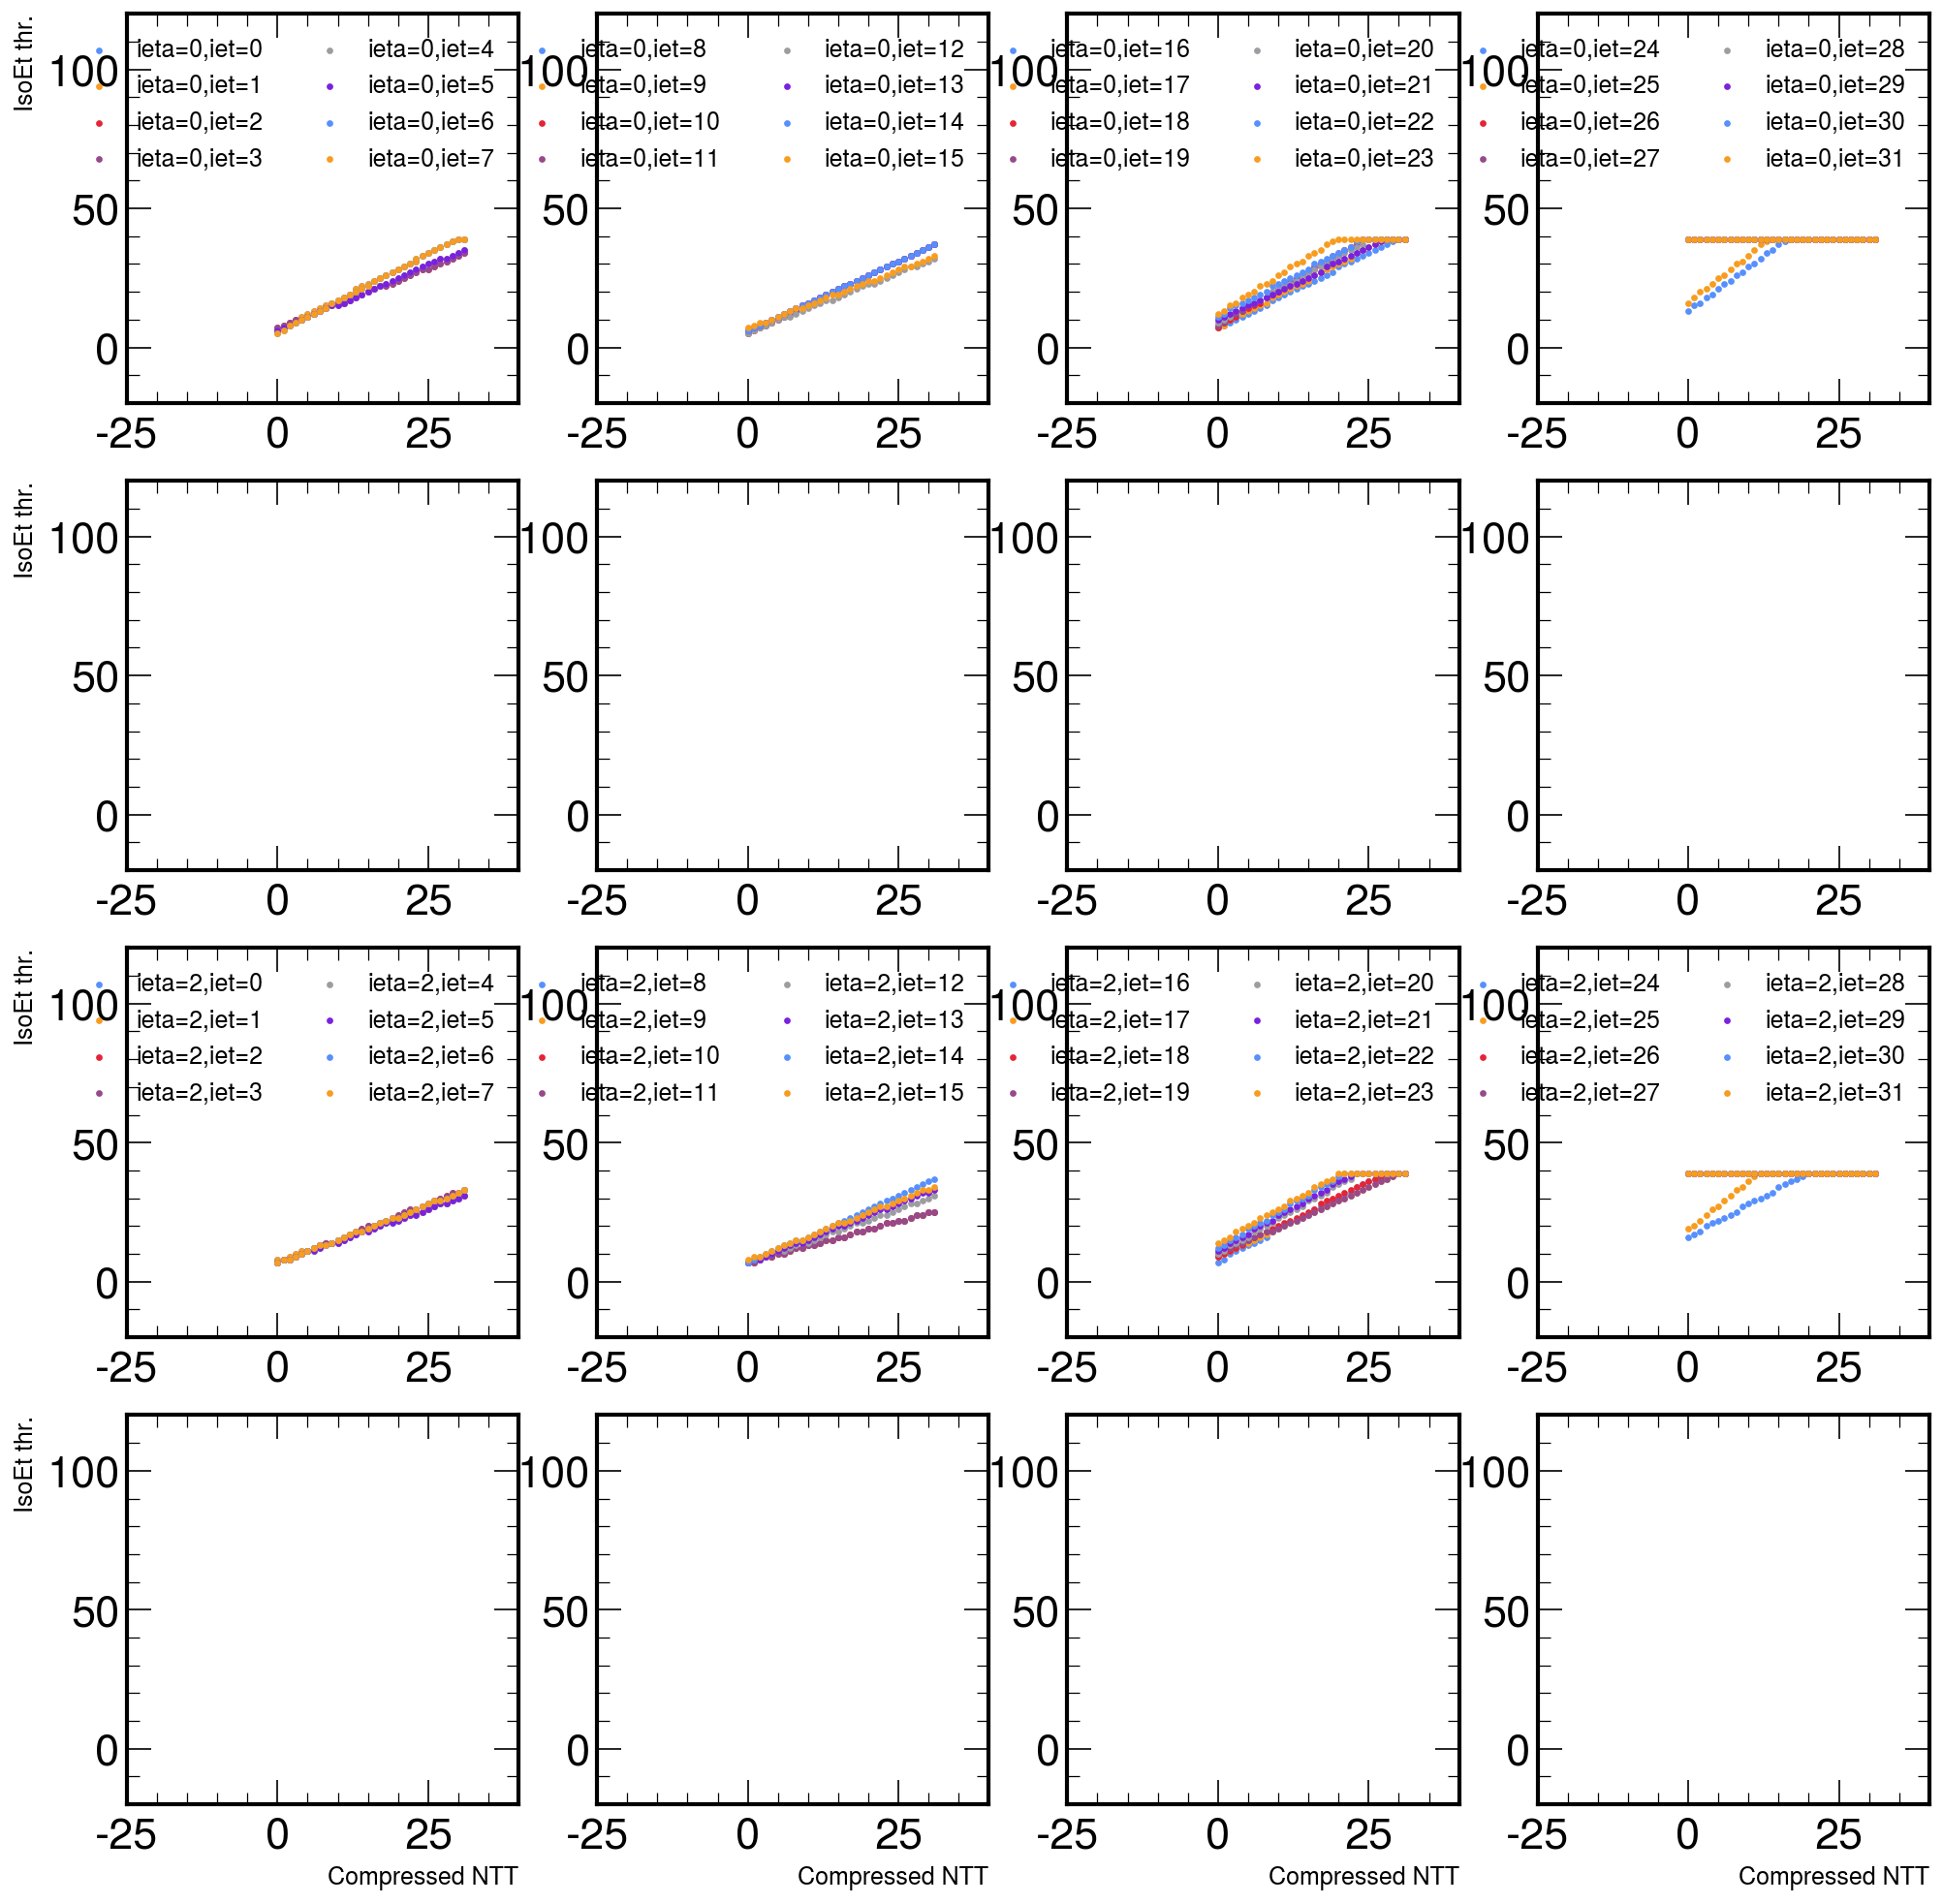

In [ ]:
f,ax=plt.subplots(4,4,figsize=(16,16),dpi=150)
ax=np.ndarray.flatten(ax)
for ietas in bin_splits['compressedIEta']:
    ieta=ietas[0]
    for iet in LUT_MAP['map'][ieta]:
        ietI=int(ieta*4 + iet/8)
        x=[]
        y=[]
        for intt in LUT_MAP['map'][ieta][iet]:
            x.append(intt)
            thr=LUT_MAP['map'][ieta][iet][intt]['threashold']
            if thr>39: thr=39
            y.append(thr)
        ax[ietI].scatter(x,y,s=5,label=f"ieta={ieta},iet={iet}")

for ieta in LUT_MAP['map']:
    for iet in LUT_MAP['map'][ieta]:
        ietI=int(ieta*4 + iet/8)
        ax[ietI].legend(ncol=2,fontsize=12)
        ax[ietI].set_ylim([-20,120])
        ax[ietI].set_xlim([-25,40])
#         ax[ietI].text(-15,20+(iet%2)*10,f"comp. iET : {iet}",fontsize=12)
        
        if (ietI%4)==0:
            ax[ietI].set_ylabel("IsoEt thr.",fontsize=12)
        if  ietI>11:
            ax[ietI].set_xlabel("Compressed NTT",fontsize=12)
    
#     break/
    

<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_963874/151253575.py:25: SyntaxWarning: invalid escape sequence '\e'
  t=ax.text(15.2,12.3,"I$\eta$ = "+str(eta) ,fontweight='bold',c='r',alpha=1)


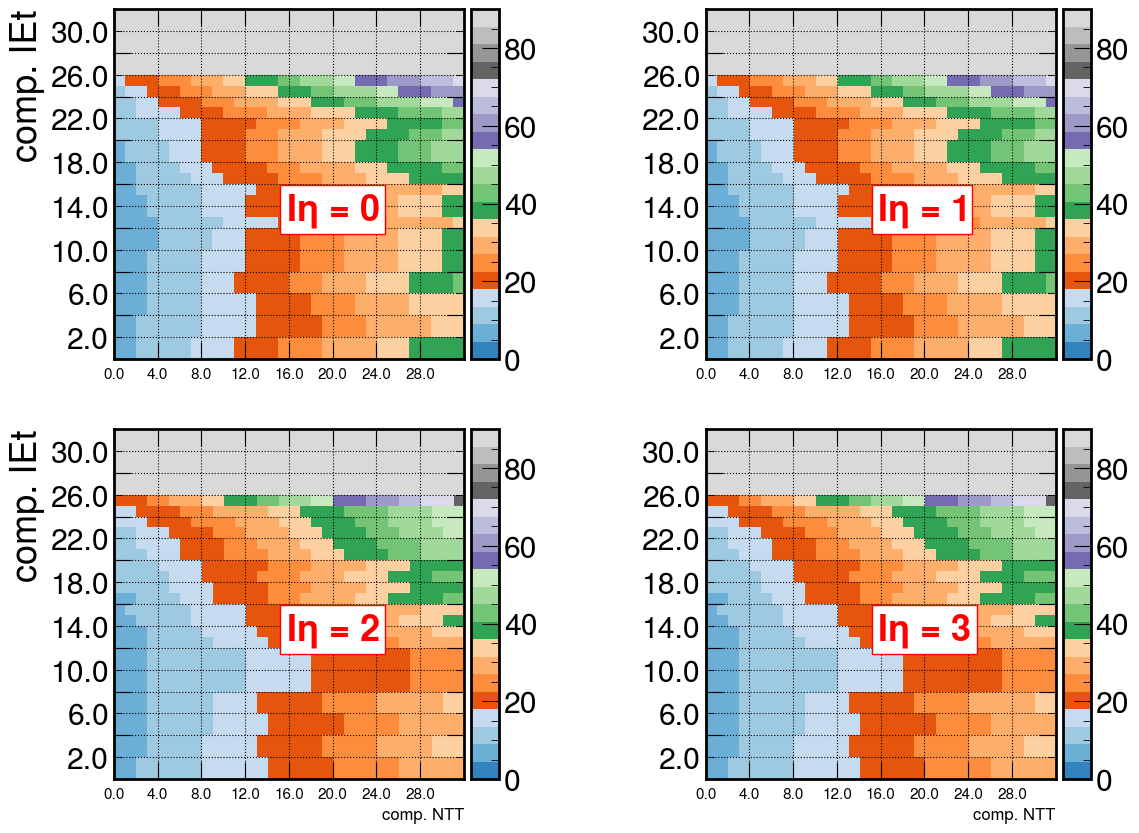

In [ ]:
if True:
    LUT=np.zeros((4,32,32),int)
    for i in LUT_MAP['map']:
        for j in LUT_MAP['map'][i]:
            for k in LUT_MAP['map'][i][j]:
                LUT[i][j][k]=LUT_MAP['map'][i][j][k]['threashold']

    f,axlist=plt.subplots(2,2,figsize=(14,10))
    axlist=np.ndarray.flatten(axlist)
    for eta in range(4):
        ax=axlist[eta]
        lut_proj=LUT[eta,:,:]
    #     f,ax=plt.subplots(figsize=(32/4,16/4))
        maxIsoEt=90
        if eta > 8:
            maxIsoEt=120
        lut_proj[lut_proj>maxIsoEt]=maxIsoEt
        c=ax.imshow(lut_proj,cmap='tab20c',origin='lower',vmin=0, vmax=maxIsoEt)
        t=ax.set_xticks(np.arange(0.0,32,4)-0.5,np.arange(0.0,32,4),minor=True)
        t=ax.set_yticks(np.arange(0.0,32,2)-0.5,np.arange(0.0,32,2),minor=True)
        t=ax.set_xticks(np.arange(0.0,32,4)-0.5,np.arange(0.0,32,4),fontsize=11)
        t=ax.set_yticks(np.arange(0.0,32,4)-0.5,np.arange(0.0,32,4),color='w',fontsize=9)
        ax2 = f.add_axes([ax.get_position().x1+0.005,ax.get_position().y0,0.02,ax.get_position().height])
        ax.grid(color='k',alpha=1,which='both')
        t=ax.text(15.2,12.3,"I$\eta$ = "+str(eta) ,fontweight='bold',c='r',alpha=1)
        t.set_bbox(dict(facecolor='w',alpha=1.0, edgecolor='r'))
        plt.colorbar(c,cax=ax2)
        if (eta%2)==0:
            ax.set_ylabel("comp. IEt")
        if eta>1:
            ax.set_xlabel("comp. NTT",fontsize=12)


In [ ]:
k=0
LUT_TEXT="""\
# Tau isolation LUT from V9 optimization for effMin 0.9 Emin 16 Emax 60
# iso LUT structure is ieta --> iEt -->  nTT
# Compr bits: ieta: 2 iEt: 5 nTT: 5
#<header> V10.0 12 9 </header>

"""
for ieta in range(nEtaBins):
    for iet in range(nEtBins):
        for intt in range(nNTTBins):
            index=LUT_MAP['index'][k]
            thr=LUT_MAP['threashold'][k]
            
            ostr=f"{index} {thr} # ieta : iEt : inTT = {ieta} : {iet} : {intt}"
            LUT_TEXT+=ostr
            LUT_TEXT+="\n"
            k+=1

foutname=f"LUT.txt"
print(foutname)
with open(foutname,'w') as f:
    f.write(LUT_TEXT)

LUT.txt
